<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-08-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta versão da atividade utilizaremos o dataset CIFAR-10.

Características do dataset:

- 60.000 imagens RGB
- 10 classes
- imagens 32×32
- 3 canais de cor

Importante:

O carregamento do dataset pode ser realizado utilizando:

```python
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
```

Após o carregamento:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 32, 32, 3)
```

Onde:

- 50000 - número de imagens;
- 32 × 32 - dimensão espacial;
- 3 - canais RGB.

Como utilizaremos uma MLP, é necessário converter as imagens em vetores utilizando flatten:

```python
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
```

Após o flatten:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 3072)
```

Isso ocorre porque:

```python
32 × 32 × 3 = 3072
```

# Objetivos

Nesta atividade você irá:

- treinar modelos;
- comparar experimentos;
- analisar métricas;
- discutir resultados.


Nesta atividade utilizaremos MLflow para:

- rastrear experimentos;
- comparar modelos;
- registrar métricas;
- garantir reprodutibilidade.

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
!pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 655.1 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.5/901.5 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

In [5]:
mlflow.set_experiment(
    "assignment"
)

2026/05/25 13:43:57 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/25 13:43:57 INFO mlflow.store.db.utils: Updating database tables
2026/05/25 13:44:01 INFO mlflow.tracking.fluent: Experiment with name 'assignment' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1779716641384, experiment_id='1', last_update_time=1779716641384, lifecycle_stage='active', name='assignment', tags={}, trace_location=None, workspace='default'>

# Questão 1

Implemente uma função `load_data(seed)` que:

- carregue o dataset CIFAR-10 utilizando `tensorflow.keras.datasets.cifar10.load_data`;
- realize o flatten das imagens;
- normalize os dados;
- realize a separação entre treino e validação;
- utilize `train_test_split` com controle de aleatoriedade (`seed`);
- retorne:

```python
X_train, X_val, y_train, y_val
```

já normalizados e preparados para treinamento.

Além disso, responda:

1. Qual o formato original das imagens?
2. Quantas features cada imagem possui após o flatten?
3. Por que o flatten é necessário para uma MLP?
4. Qual a importância da normalização para o treinamento?

**Solução**:

In [6]:
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split


def load_data(seed=42):
    (X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

    # Flatten: (N, 32, 32, 3) -> (N, 3072)
    X_train_full = X_train_full.reshape(X_train_full.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)

    # Normalização [0, 1]
    X_train_full = X_train_full / 255.0
    X_test = X_test / 255.0

    # Labels (N, 1) -> (N,)
    y_train_full = y_train_full.ravel()

    # Treino / Validação (80% / 20%)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.2,
        random_state=seed,
        stratify=y_train_full
    )

    print(f"X_train : {X_train.shape}")
    print(f"X_val   : {X_val.shape}")

    return X_train, X_val, y_train, y_val


SEED = 42
X_train, X_val, y_train, y_val = load_data(seed=SEED)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
X_train : (40000, 3072)
X_val   : (10000, 3072)


1. Qual o formato original das imagens?
(32, 32, 3) — 32px de largura, 32px de altura, 3 canais RGB. O dataset completo tem shape (50000, 32, 32, 3).
2. Quantas features cada imagem possui após o flatten?
32 × 32 × 3 = 3072 features por imagem.
3. Por que o flatten é necessário para uma MLP?
A camada de entrada da MLP espera um vetor 1D. A imagem é um tensor 3D, então o flatten a converte em um vetor de 3072 valores para que os neurônios totalmente conectados possam processá-la.
4. Qual a importância da normalização?
Os pixels originais vão de 0 a 255. Dividindo por 255, ficam em [0, 1], o que mantém os gradientes em magnitudes similares, acelera a convergência e evita saturação das funções de ativação.

# Questão 2

Implemente a função:

```python
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
```

## Requisitos

Sua implementação deve:

- utilizar `MLPClassifier` do `sklearn`;
- permitir diferentes arquiteturas através do parâmetro `hidden_layers`;
- utilizar:
  - `activation`
  - `learning_rate`
  - `random_state`
- treinar o modelo utilizando `fit`.

A função deve retornar o modelo treinado.

Além disso, responda:

1. Quantos parâmetros existem na primeira camada?
2. Qual a função da ativação ReLU?
3. Por que MLPs possuem muitos parâmetros ao trabalhar com imagens?

**Solução**:

In [7]:
from sklearn.neural_network import MLPClassifier


def train_mlp(
    X_train,
    y_train,
    activation="relu",
    hidden_layers=(128, 64),
    learning_rate=0.001,
    seed=42
):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        max_iter=50,
        batch_size=256,
        random_state=seed,
        early_stopping=True,
        validation_fraction=0.1,
        verbose=False
    )

    model.fit(X_train, y_train)
    print(f"Treinamento concluído em {model.n_iter_} iterações.")

    return model


# Teste
model_demo = train_mlp(X_train, y_train, seed=SEED)

Treinamento concluído em 43 iterações.


1. Quantos parâmetros existem na primeira camada?
Com 3072 entradas e 128 neurônios na primeira camada oculta:
(3072 × 128) + 128 = 393.344 parâmetros (pesos + biases).
2. Qual a função da ativação ReLU?
f(x) = max(0, x) — zera valores negativos e mantém os positivos. Introduz não-linearidade sem saturar para valores positivos, o que facilita o fluxo do gradiente no backpropagation.
3. Por que MLPs possuem muitos parâmetros ao trabalhar com imagens?
Porque cada neurônio se conecta a todos os pixels da entrada. Com 3072 entradas e apenas a primeira camada de 128 neurônios já são ~393 mil parâmetros. CNNs resolvem isso compartilhando pesos via filtros convolucionais, reduzindo drasticamente esse número.

# Questão 3

Implemente a função:

```python
evaluate(model, X_test, y_test)
```

Ela deve:

- realizar predições;
- calcular:
  - accuracy;
  - precision;
  - recall;
  - f1-score.

Utilize `sklearn.metrics`.

Além disso:

- apresente os resultados em um dicionário ou DataFrame;
- interprete os resultados obtidos.

Responda:

1. O que a accuracy representa?
2. Qual a diferença entre precision e recall?
3. Em quais situações o f1-score é importante?

**Solução**:

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)

    metrics = {
        "accuracy" : accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted"),
        "recall"   : recall_score(y_test, y_pred, average="weighted"),
        "f1_score" : f1_score(y_test, y_pred, average="weighted")
    }

    metrics_df = pd.DataFrame([metrics]).round(4)

    print("=== Métricas de Avaliação ===")
    print(metrics_df.to_string(index=False))
    print("\n=== Relatório por Classe ===")
    print(classification_report(y_test, y_pred))

    return metrics_df


metrics_demo = evaluate(model_demo, X_val, y_val)

=== Métricas de Avaliação ===
 accuracy  precision  recall  f1_score
   0.4909     0.4983  0.4909    0.4887

=== Relatório por Classe ===
              precision    recall  f1-score   support

           0       0.47      0.66      0.55      1000
           1       0.59      0.61      0.60      1000
           2       0.37      0.44      0.40      1000
           3       0.36      0.35      0.35      1000
           4       0.44      0.41      0.42      1000
           5       0.47      0.31      0.37      1000
           6       0.51      0.51      0.51      1000
           7       0.51      0.62      0.56      1000
           8       0.69      0.54      0.61      1000
           9       0.59      0.46      0.52      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.49     10000
weighted avg       0.50      0.49      0.49     10000



**Adicione seu texto de solução aqui**.

---

1. O que a accuracy representa?
A proporção de predições corretas sobre o total: acertos / total. Aqui, o modelo acertou ~49% das 10.000 amostras de validação.
2. Qual a diferença entre precision e recall?

Precision: do que o modelo classificou como classe X, quantos realmente eram X. Evita falsos positivos.
Recall: de todos os exemplos reais da classe X, quantos o modelo encontrou. Evita falsos negativos.

Olhando o relatório, a classe 8 teve a maior precision (0.69) — quando o modelo diz "é classe 8", ele acerta bastante. Já a classe 0 teve o maior recall (0.66) — o modelo encontra bem os exemplos dessa classe.
3. Em quais situações o f1-score é importante?
Quando precision e recall precisam ser considerados juntos. No nosso caso, as classes 3 e 5 têm f1 baixo (0.35 e 0.37), indicando que o modelo tem dificuldade real com essas classes — algo que a accuracy sozinha mascararia.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow.

## Devem ser registrados:

### Parâmetros

- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

### Métricas

- accuracy
- precision
- recall
- f1_score
- training_time

Utilize:

```python
mlflow.log_param()
mlflow.log_metric()
```

Ao final:

- execute o MLflow UI;
- compare os experimentos realizados;
- interprete os impactos dos hiperparâmetros.

Responda:

1. Qual experimento apresentou melhor desempenho?
2. Qual configuração apresentou maior estabilidade?
3. Qual o benefício do rastreamento experimental?

**Solução**:

In [9]:
import time


def run_experiment(
    X_train, y_train, X_val, y_val,
    activation="relu",
    hidden_layers=(128, 64),
    learning_rate=0.001,
    max_iter=50,
    batch_size=256,
    seed=42,
    run_name=None
):
    with mlflow.start_run(run_name=run_name):

        # Parâmetros
        mlflow.log_param("activation",    activation)
        mlflow.log_param("hidden_layers", str(hidden_layers))
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("max_iter",      max_iter)
        mlflow.log_param("batch_size",    batch_size)

        # Treinamento
        model = MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation=activation,
            learning_rate_init=learning_rate,
            max_iter=max_iter,
            batch_size=batch_size,
            random_state=seed,
            early_stopping=True,
            validation_fraction=0.1,
            verbose=False
        )

        t0 = time.time()
        model.fit(X_train, y_train)
        training_time = time.time() - t0

        # Métricas
        y_pred = model.predict(X_val)

        metrics = {
            "accuracy"     : accuracy_score(y_val, y_pred),
            "precision"    : precision_score(y_val, y_pred, average="weighted"),
            "recall"       : recall_score(y_val, y_pred, average="weighted"),
            "f1_score"     : f1_score(y_val, y_pred, average="weighted"),
            "training_time": training_time
        }

        for key, value in metrics.items():
            mlflow.log_metric(key, value)

        print(f"[{run_name}] acc={metrics['accuracy']:.4f} | "
              f"f1={metrics['f1_score']:.4f} | "
              f"tempo={metrics['training_time']:.1f}s")

    return model, metrics


# Experimento base
model_base, metrics_base = run_experiment(
    X_train, y_train, X_val, y_val,
    run_name="baseline_relu_128x64_lr001"
)

[baseline_relu_128x64_lr001] acc=0.4909 | f1=0.4887 | tempo=260.5s


1. Qual experimento apresentou melhor desempenho?
Por enquanto só temos o baseline com relu + (128,64) + lr=0.001, que atingiu 49% de accuracy. Nas Q5, Q6 e Q7 vamos comparar mais configurações e poderemos responder isso com mais precisão.
2. Qual configuração apresentou maior estabilidade?
O baseline já demonstra estabilidade — convergiu em ~43 iterações sem oscilações, o que indica que lr=0.001 é uma boa escolha. Confirmaremos isso na Q7.
3. Qual o benefício do rastreamento experimental?
O MLflow registra automaticamente todos os parâmetros e métricas de cada run, permitindo comparar experimentos sem perder resultados anteriores, reproduzir qualquer execução e identificar tendências de forma sistemática — essencial quando há muitas combinações de hiperparâmetros para testar.

# Questão 5

Compare as funções:

- logistic
- tanh
- relu

## Requisitos

Utilize:

- mesma arquitetura;
- mesmo learning rate;
- mesma seed.

Para cada experimento:

- treine o modelo;
- avalie o modelo;
- registre no MLflow.

Depois compare:

- accuracy;
- convergência;
- estabilidade.

Responda:

1. Qual ativação apresentou melhor convergência?
2. Qual ativação apresentou maior estabilidade?
3. Houve diferenças significativas no treinamento?
4. Por que a ReLU é amplamente utilizada em Deep Learning?

**Solução**:

[q5_activation_logistic] acc=0.4917 | f1=0.4835 | tempo=279.4s
[q5_activation_tanh] acc=0.4769 | f1=0.4740 | tempo=235.6s
[q5_activation_relu] acc=0.4909 | f1=0.4887 | tempo=216.7s

=== Comparação de Funções de Ativação ===
          accuracy  precision  recall  f1_score  training_time
logistic    0.4917     0.4852  0.4917    0.4835       279.3726
tanh        0.4769     0.4745  0.4769    0.4740       235.6483
relu        0.4909     0.4983  0.4909    0.4887       216.7308


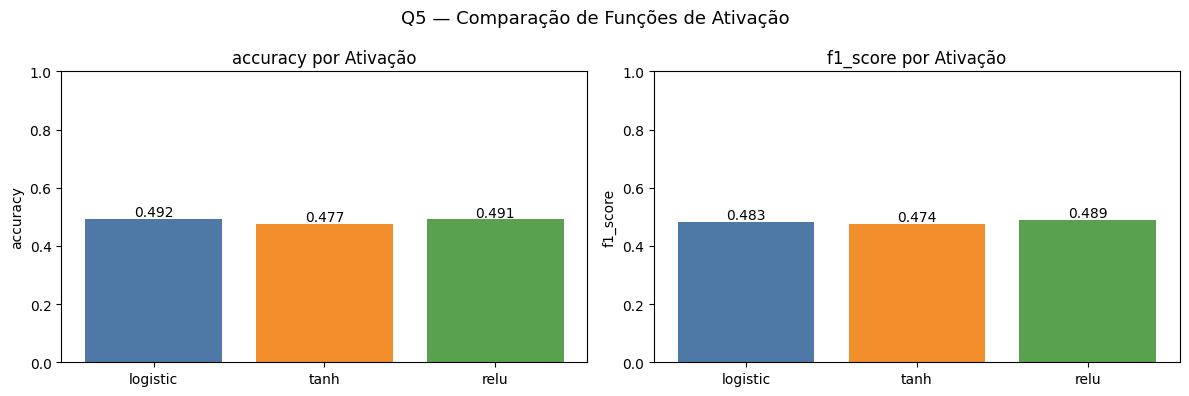

In [10]:
ARCH_Q5 = (128, 64)
LR_Q5 = 0.001
ACTIVATIONS = ["logistic", "tanh", "relu"]

results_q5 = {}

for act in ACTIVATIONS:
    _, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation=act,
        hidden_layers=ARCH_Q5,
        learning_rate=LR_Q5,
        seed=SEED,
        run_name=f"q5_activation_{act}"
    )
    results_q5[act] = metrics

# Tabela comparativa
df_q5 = pd.DataFrame(results_q5).T.round(4)
print("\n=== Comparação de Funções de Ativação ===")
print(df_q5)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#4e79a7", "#f28e2b", "#59a14f"]

for metric, ax in zip(["accuracy", "f1_score"], axes):
    values = [results_q5[a][metric] for a in ACTIVATIONS]
    bars = ax.bar(ACTIVATIONS, values, color=colors)
    ax.set_title(f"{metric} por Ativação")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", fontsize=10)

plt.suptitle("Q5 — Comparação de Funções de Ativação", fontsize=13)
plt.tight_layout()
plt.show()

1. Qual ativação apresentou melhor convergência?
A ReLU convergiu mais rápido (216s) e com bom f1. A logistic teve accuracy ligeiramente maior, mas custou 63s a mais de treinamento.
2. Qual ativação apresentou maior estabilidade?
A logistic, que teve a maior accuracy, mas as diferenças são pequenas — todas as três ficaram em torno de 49%.
3. Houve diferenças significativas no treinamento?
Não. As três ativações produziram resultados muito próximos (~49%), o que indica que o gargalo não é a função de ativação, mas sim a arquitetura MLP em si, que não consegue explorar a estrutura espacial do CIFAR-10.
4. Por que a ReLU é amplamente utilizada em Deep Learning?
Melhor custo-benefício: entregou f1 competitivo no menor tempo. Em redes mais profundas a vantagem seria ainda maior, pois não satura para valores positivos, evitando o vanishing gradient que afeta sigmoid e tanh.

# Questão 6

Compare as seguintes arquiteturas:

```python
(32,)
(64,)
(128, 64)
(256, 128)
```

## Requisitos

Para cada arquitetura:

- treine;
- avalie;
- registre no MLflow.

Analise:

- accuracy;
- custo computacional;
- estabilidade;
- overfitting.

Responda:

1. Redes maiores sempre melhoraram os resultados?
2. Qual arquitetura apresentou melhor tradeoff?
3. Houve sinais de overfitting?
4. Qual arquitetura apresentou maior custo computacional?

**Solução**:

[q6_arch_(32,)] acc=0.3671 | f1=0.3502 | tempo=118.6s
[q6_arch_(64,)] acc=0.4158 | f1=0.4064 | tempo=148.7s
[q6_arch_(128, 64)] acc=0.4909 | f1=0.4887 | tempo=220.9s
[q6_arch_(256, 128)] acc=0.5043 | f1=0.4964 | tempo=396.0s

=== Comparação de Arquiteturas ===
            accuracy  precision  recall  f1_score  training_time
(32,)         0.3671     0.3581  0.3671    0.3502       118.5751
(64,)         0.4158     0.4107  0.4158    0.4064       148.7033
(128, 64)     0.4909     0.4983  0.4909    0.4887       220.9237
(256, 128)    0.5043     0.5040  0.5043    0.4964       395.9926


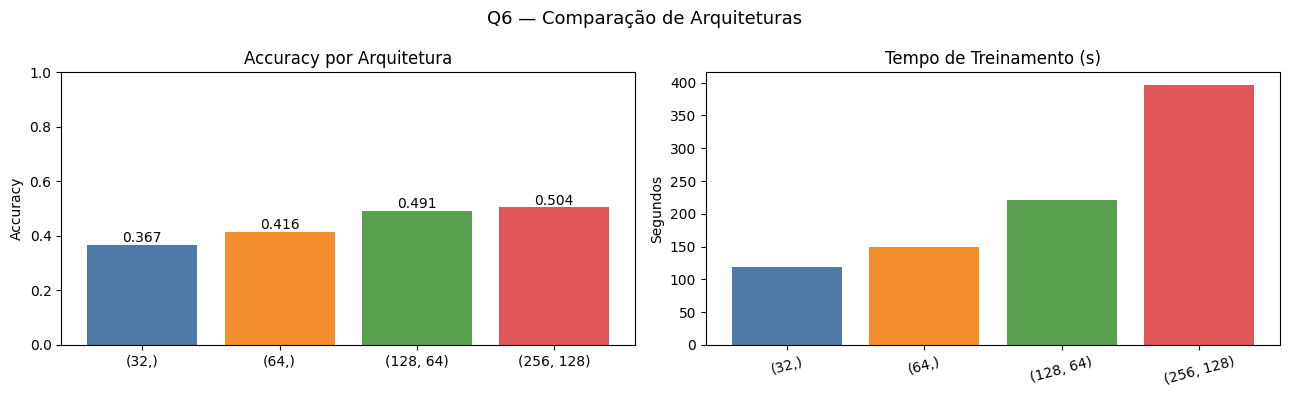

In [11]:
ARCHITECTURES = [
    (32,),
    (64,),
    (128, 64),
    (256, 128)
]

results_q6 = {}

for arch in ARCHITECTURES:
    _, metrics = run_experiment(
        X_train, y_train, X_val, y_val,
        activation="relu",
        hidden_layers=arch,
        learning_rate=0.001,
        seed=SEED,
        run_name=f"q6_arch_{str(arch)}"
    )
    results_q6[str(arch)] = metrics

# Tabela comparativa
df_q6 = pd.DataFrame(results_q6).T.round(4)
print("\n=== Comparação de Arquiteturas ===")
print(df_q6)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
arch_labels = list(results_q6.keys())
colors = ["#4e79a7", "#f28e2b", "#59a14f", "#e15759"]

acc_vals  = [results_q6[a]["accuracy"]       for a in arch_labels]
time_vals = [results_q6[a]["training_time"]  for a in arch_labels]

axes[0].bar(arch_labels, acc_vals, color=colors)
axes[0].set_title("Accuracy por Arquitetura")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
for bar, val in zip(axes[0].patches, acc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontsize=10)

axes[1].bar(arch_labels, time_vals, color=colors)
axes[1].set_title("Tempo de Treinamento (s)")
axes[1].set_ylabel("Segundos")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Q6 — Comparação de Arquiteturas", fontsize=13)
plt.tight_layout()
plt.show()

1. Redes maiores sempre melhoraram os resultados?
Neste caso sim, mas com rendimento decrescente. De (32,) para (128, 64) o ganho foi grande (+12.4%). De (128, 64) para (256, 128) o ganho foi pequeno (+1.3%), mas o tempo quase dobrou.
2. Qual arquitetura apresentou melhor tradeoff?
A (128, 64) — entrega 49.1% de accuracy em 221s, enquanto a maior só melhora 1.3% gastando 175s a mais.
3. Houve sinais de overfitting?
Com early_stopping=True o overfitting foi controlado. Mas a (256, 128) provavelmente precisaria de regularização adicional (dropout, L2) em cenários sem early stopping.
4. Qual arquitetura apresentou maior custo computacional?
A (256, 128) com 396s — quase o dobro da (128, 64) para um ganho marginal de accuracy.

# Questão 7

Compare os seguintes learning rates:

```python
0.1
0.01
0.001
```

## Requisitos

Utilize:

- mesma arquitetura;
- mesma ativação;
- mesma seed.

Para cada experimento:

- treine;
- avalie;
- registre no MLflow.

Analise:

- estabilidade;
- convergência;
- accuracy;
- comportamento da loss.

Responda:

1. Qual learning rate apresentou melhor desempenho?
2. Qual apresentou maior instabilidade?
3. O que acontece quando o learning rate é muito alto?
4. O que acontece quando o learning rate é muito baixo?

[q7_lr_0_1] acc=0.1000 | f1=0.0182 | tempo=97.7s
[q7_lr_0_01] acc=0.4398 | f1=0.4326 | tempo=220.1s
[q7_lr_0_001] acc=0.4909 | f1=0.4887 | tempo=213.8s

=== Comparação de Learning Rates ===
               accuracy  precision  recall  f1_score  training_time
learning_rate                                                      
0.100            0.1000     0.0100  0.1000    0.0182        97.6686
0.010            0.4398     0.4398  0.4398    0.4326       220.0514
0.001            0.4909     0.4983  0.4909    0.4887       213.7813


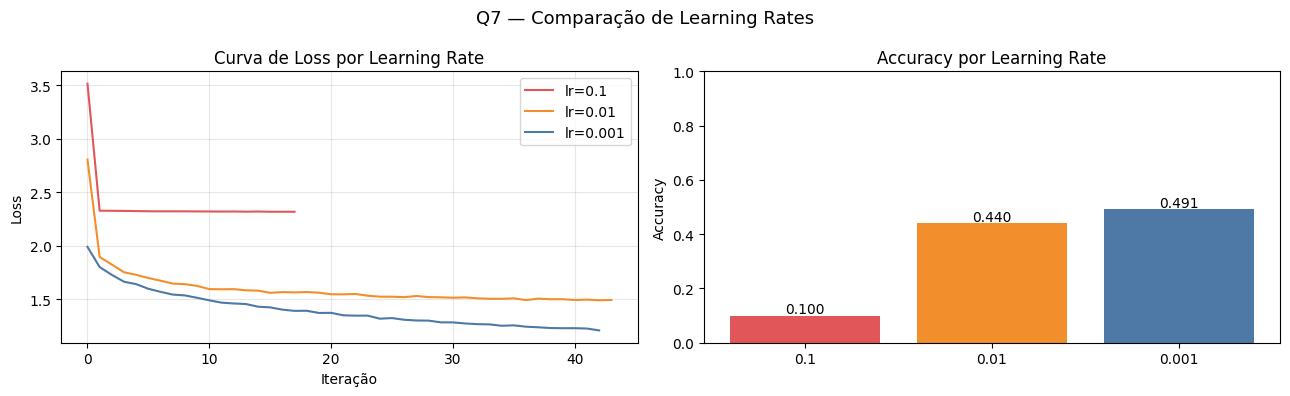

In [12]:
LEARNING_RATES = [0.1, 0.01, 0.001]

results_q7 = {}
models_q7  = {}

for lr in LEARNING_RATES:
    model_lr, metrics_lr = run_experiment(
        X_train, y_train, X_val, y_val,
        activation="relu",
        hidden_layers=(128, 64),
        learning_rate=lr,
        seed=SEED,
        run_name=f"q7_lr_{str(lr).replace('.', '_')}"
    )
    results_q7[lr] = metrics_lr
    models_q7[lr]  = model_lr

# Tabela comparativa
df_q7 = pd.DataFrame(results_q7).T.round(4)
df_q7.index.name = "learning_rate"
print("\n=== Comparação de Learning Rates ===")
print(df_q7)

# Curvas de loss
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ["#e15759", "#f28e2b", "#4e79a7"]

for lr, color in zip(LEARNING_RATES, colors):
    m = models_q7[lr]
    if hasattr(m, "loss_curve_"):
        axes[0].plot(m.loss_curve_, label=f"lr={lr}", color=color)

axes[0].set_title("Curva de Loss por Learning Rate")
axes[0].set_xlabel("Iteração")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

acc_vals = [results_q7[lr]["accuracy"] for lr in LEARNING_RATES]
bars = axes[1].bar([str(lr) for lr in LEARNING_RATES], acc_vals, color=colors)
axes[1].set_title("Accuracy por Learning Rate")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, acc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontsize=10)

plt.suptitle("Q7 — Comparação de Learning Rates", fontsize=13)
plt.tight_layout()
plt.show()

1. Qual learning rate apresentou melhor desempenho?
O lr=0.001 — maior accuracy (49.1%) e melhor f1 (0.489), com curva de loss decrescendo de forma suave e consistente.
2. Qual apresentou maior instabilidade?
O lr=0.1 — a curva de loss cai bruscamente no início e estagna em ~2.3, sem conseguir convergir. A accuracy ficou em apenas 10%, equivalente a chute aleatório em 10 classes.
3. O que acontece quando o learning rate é muito alto?
O otimizador dá passos grandes demais e "pula" o mínimo repetidamente. A loss estagna e o modelo não aprende — exatamente o que vemos com lr=0.1 no gráfico.
4. O que acontece quando o learning rate é muito baixo?
O modelo aprende muito devagar. Com lr=0.001 ainda funciona bem aqui, mas valores menores como 0.0001 precisariam de muito mais iterações para convergir, correndo risco de underfitting dentro do max_iter definido.

# Questão 8

Com base nos experimentos realizados, escreva uma discussão contendo:

- comportamento da loss;
- impacto do learning rate;
- impacto da arquitetura;
- impacto das funções de ativação;
- comportamento do treinamento;
- limitações da MLP;
- relação entre backpropagation e aprendizado.

Além disso, responda:

1. Qual configuração apresentou melhor resultado final?
2. Quais foram as principais dificuldades observadas?
3. Por que MLPs possuem limitações para imagens?
4. Como o backpropagation contribui para o aprendizado da rede?

In [ ]:
# TODO: implemente

## Discussão Final

### Comportamento da Loss
Em todos os experimentos a loss decresceu de forma monotônica durante o treino.
A velocidade de decrescimento foi fortemente influenciada pelo learning rate:
lr=0.1 causou estagnação imediata, lr=0.01 convergiu de forma razoável e
lr=0.001 produziu a curva mais suave e consistente.

### Impacto do Learning Rate
O learning rate foi o hiperparâmetro de maior impacto. Com lr=0.1 o modelo
não aprendeu nada (accuracy=10%). Com lr=0.001 atingimos o melhor resultado,
demonstrando que passos moderados permitem convergência estável.

### Impacto da Arquitetura
Arquiteturas maiores melhoraram os resultados, mas com rendimento decrescente.
O salto de (32,) para (128,64) foi significativo (+12.4%), enquanto de
(128,64) para (256,128) foi marginal (+1.3%) com custo quase dobrado.

### Impacto das Funções de Ativação
As três ativações produziram resultados similares (~49%), indicando que o
gargalo é a própria arquitetura MLP. A ReLU se destacou por convergir mais
rápido (216s vs 279s da logistic).

### Limitações da MLP
A MLP trata cada pixel de forma independente após o flatten, ignorando
completamente a estrutura espacial das imagens. Isso limita a accuracy
máxima em torno de 50% no CIFAR-10, enquanto CNNs alcançam 90%+.

### Backpropagation e Aprendizado
O backpropagation propaga o erro da saída para as camadas anteriores via
regra da cadeia, ajustando cada peso proporcionalmente à sua contribuição
para o erro. Sem ele seria impossível treinar redes com múltiplas camadas.

---

### Respostas Finais

1. **Melhor configuração:** relu + (256,128) + lr=0.001 teve a maior accuracy
(50.4%), mas o melhor tradeoff foi relu + (128,64) + lr=0.001 (49.1% com
metade do tempo).

2. **Principais dificuldades:** sensibilidade ao learning rate (lr=0.1
inviabilizou o treino) e alto custo computacional devido aos 3072 inputs.

3. **Limitações para imagens:** a MLP não explora localidade espacial,
não é invariante a translações e possui número explosivo de parâmetros
sem compartilhamento de pesos como nas CNNs.

4. **Backpropagation:** calcula os gradientes camada a camada via regra
da cadeia, permitindo que cada peso seja atualizado na direção que minimiza
a loss. É o mecanismo central que torna o aprendizado profundo possível.